# Estadística básica — ejemplos en código

**Curso:** Fundamentos para Inteligencia Artificial — NRC 94103
**Semana 5:** Estadística básica y visualización de datos
**Datos:** `StudentsPerformance.csv` — notas de 1000 estudiantes (matemáticas, lectura y escritura), más algunos datos de contexto (género, almuerzo, curso de preparación, etc.)

Este notebook es la versión "en código" del documento [`explicacion.md`](Estadistica_Basica.md) de esta misma carpeta. Cada bloque tiene primero una explicación sencilla y luego el código que la calcula, para que puedas ejecutarlo y ver los resultados con tus propios datos.

**Cómo usar este notebook:** ejecuta las celdas en orden, de arriba hacia abajo, con `Shift + Enter`. No necesitas modificar nada para que funcione — está pensado para que lo leas, lo corras y experimentes cambiando valores si quieres.

---

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv('StudentsPerformance.csv')

print(f"Filas (estudiantes): {df.shape[0]}")
print(f"Columnas: {df.shape[1]}")
df.head()

Filas (estudiantes): 1000
Columnas: 8


,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


## 1. Contar cosas: frecuencias

Con las columnas de categorías (palabras, no números) lo primero que hacemos es contar cuántas veces aparece cada valor. Por ejemplo, ¿cuántos estudiantes hombres y cuántas mujeres hay?

Frecuencia absoluta:
gender
female    518
male      482
Name: count, dtype: int64

Frecuencia relativa (%):
gender
female    51.8
male      48.2
Name: proportion, dtype: float64


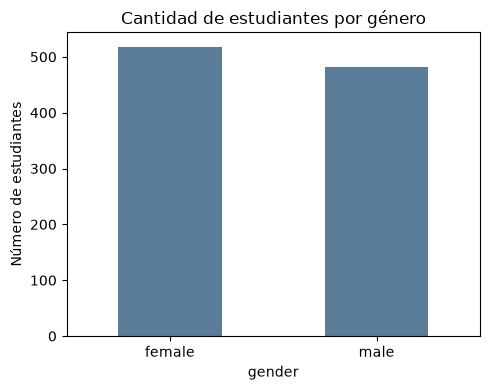

In [2]:
# Frecuencia absoluta (conteo) y relativa (porcentaje)
frecuencia = df['gender'].value_counts()
porcentaje = df['gender'].value_counts(normalize=True) * 100

print("Frecuencia absoluta:")
print(frecuencia)
print("Frecuencia relativa (%):")
print(porcentaje.round(1))

frecuencia.plot(kind='bar', color='#5a7d9a', figsize=(5, 4), rot=0)
plt.title('Cantidad de estudiantes por género')
plt.ylabel('Número de estudiantes')
plt.tight_layout()
plt.show()

## 2. El "dato típico": media, mediana y moda

Ahora trabajamos con una columna numérica: `math score` (la nota de matemáticas, de 0 a 100). Queremos saber cuál es un valor "normal" en esta columna, y hay tres formas de responder esa pregunta.

In [3]:
math = df['math score']

media = math.mean()
mediana = math.median()
moda = math.mode()[0]

print(f"Media (promedio):  {media:.2f}")
print(f"Mediana (el del medio): {mediana}")
print(f"Moda (la más repetida): {moda}")

Media (promedio):  66.09
Mediana (el del medio): 66.0
Moda (la más repetida): 65


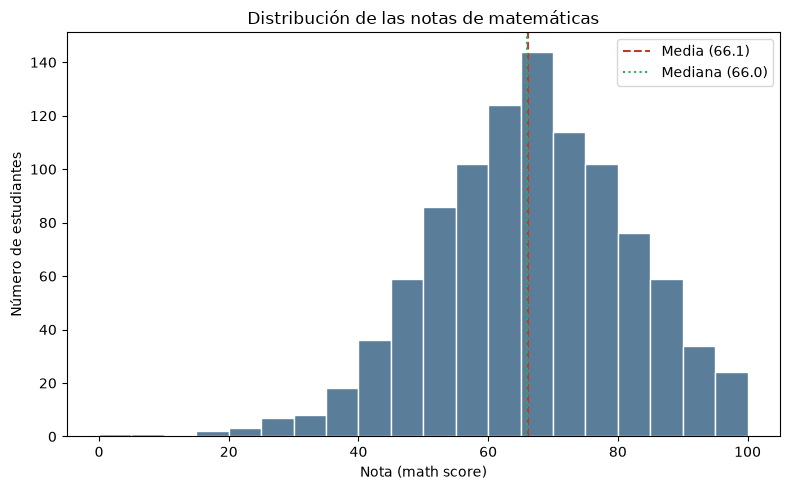

In [4]:
# Visualización: histograma de las notas de matemáticas + media y mediana
plt.figure(figsize=(8, 5))
plt.hist(math, bins=20, color='#5a7d9a', edgecolor='white')
plt.axvline(media, color='#c0392b', linestyle='--', label=f'Media ({media:.1f})')
plt.axvline(mediana, color='#27ae60', linestyle=':', label=f'Mediana ({mediana:.1f})')

plt.title('Distribución de las notas de matemáticas')
plt.xlabel('Nota (math score)')
plt.ylabel('Número de estudiantes')
plt.legend()
plt.tight_layout()
plt.show()

**Lectura:** la media y la mediana están casi pegadas (≈66), y en el histograma se ve una forma de "campana" bastante simétrica alrededor de ese valor. Eso quiere decir que las notas de matemáticas están repartidas de forma pareja, sin un grupo extremo que descuadre el promedio.

---

## 3. ¿Qué tan parejos son los datos? (dispersión)

Saber el promedio no basta: dos cursos pueden tener el mismo promedio y ser muy distintos (uno parejo, otro con notas muy repartidas). Para eso medimos el **rango** (distancia entre el mínimo y el máximo) y la **desviación estándar** (en promedio, qué tan lejos está cada nota de la media).

In [5]:
rango = math.max() - math.min()
desviacion = math.std(ddof=0)

print(f"Nota mínima:        {math.min()}")
print(f"Nota máxima:        {math.max()}")
print(f"Rango:               {rango}")
print(f"Desviación estándar: {desviacion:.2f}")
print(f"\nEs decir: la mayoría de las notas está entre {media - desviacion:.0f} y {media + desviacion:.0f} (media ± 1 desviación estándar)")

Nota mínima:        0
Nota máxima:        100
Rango:               100
Desviación estándar: 15.16

Es decir: la mayoría de las notas está entre 51 y 81 (media ± 1 desviación estándar)


## 4. Cuartiles: dividir el curso en 4 grupos iguales

Si ordenamos a los 1000 estudiantes de la nota más baja a la más alta y los dividimos en 4 grupos iguales (250 cada uno), los puntos de corte se llaman cuartiles (Q1, Q2, Q3). Sirven para saber, por ejemplo, si un estudiante quedó entre el 25% con mejores notas.

Q1 (25%): 57.0
Q2 (50%, la mediana): 66.0
Q3 (75%): 77.0
Rango intercuartílico (IQR = Q3 - Q1): 20.0

¿Una nota de 80 está en el 25% superior? Sí


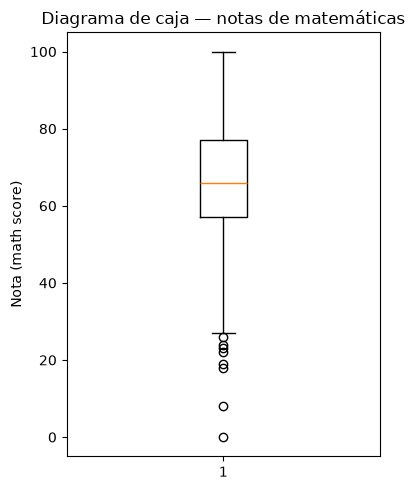

In [6]:
q1, q2, q3 = math.quantile([0.25, 0.5, 0.75])
iqr = q3 - q1

print(f"Q1 (25%): {q1}")
print(f"Q2 (50%, la mediana): {q2}")
print(f"Q3 (75%): {q3}")
print(f"Rango intercuartílico (IQR = Q3 - Q1): {iqr}")

# Ejemplo: ¿un estudiante con 80 en matemáticas quedó entre el 25% con mejores notas?
nota_ejemplo = 80
print(f"\n¿Una nota de {nota_ejemplo} está en el 25% superior? {'Sí' if nota_ejemplo > q3 else 'No'}")

# Diagrama de caja (boxplot): forma visual estándar de mostrar cuartiles
plt.figure(figsize=(4, 5))
plt.boxplot(math, orientation='vertical')
plt.title('Diagrama de caja — notas de matemáticas')
plt.ylabel('Nota (math score)')
plt.tight_layout()
plt.show()

La caja del diagrama va de Q1 a Q3 (el 50% central de las notas), la línea del medio es la mediana, y los "bigotes" muestran hasta dónde llegan los datos normales — los puntos sueltos fuera de los bigotes (si los hay) serían notas atípicas (outliers).

---

## 5. Comparar grupos: ¿sirvió el curso de preparación?

Ahora comparamos el promedio de matemáticas entre los estudiantes que hicieron el curso de preparación y los que no.

test preparation course
completed    69.70
none         64.08
Name: math score, dtype: float64


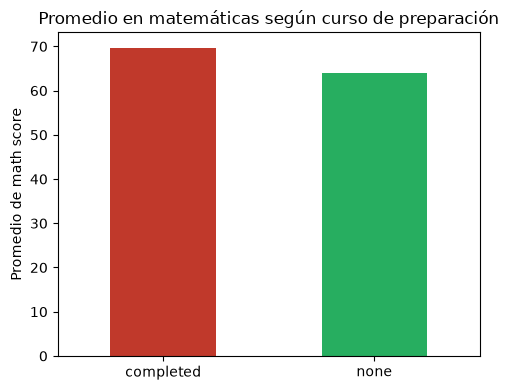

In [7]:
promedio_por_grupo = df.groupby('test preparation course')['math score'].mean()
print(promedio_por_grupo.round(2))

promedio_por_grupo.plot(kind='bar', color=['#c0392b', '#27ae60'], figsize=(5, 4), rot=0)
plt.title('Promedio en matemáticas según curso de preparación')
plt.ylabel('Promedio de math score')
plt.xlabel('')
plt.tight_layout()
plt.show()

**Lectura:** los que completaron el curso de preparación sacaron, en promedio, casi 6 puntos más. Eso no prueba que el curso *cause* la diferencia (a lo mejor los estudiantes más aplicados son los que deciden tomarlo), pero sí es una pista fuerte que valdría la pena investigar más a fondo.

---

## 6. Correlación: si mejoras en una materia, ¿mejoras en otra?

La correlación mide qué tanto se mueven juntas dos columnas numéricas. Va de -1 a 1: cerca de 1 significa que suben juntas, cerca de -1 que una sube cuando la otra baja, y cerca de 0 que no hay relación clara.

In [8]:
corr_mat_read = df['math score'].corr(df['reading score'])
corr_mat_write = df['math score'].corr(df['writing score'])
corr_read_write = df['reading score'].corr(df['writing score'])

print(f"Matemáticas vs. Lectura:   {corr_mat_read:.3f}")
print(f"Matemáticas vs. Escritura: {corr_mat_write:.3f}")
print(f"Lectura vs. Escritura:     {corr_read_write:.3f}")

Matemáticas vs. Lectura:   0.818
Matemáticas vs. Escritura: 0.803
Lectura vs. Escritura:     0.955


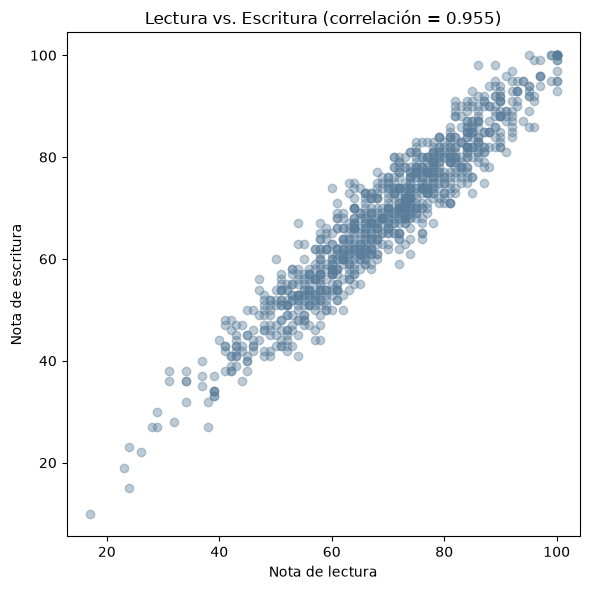

In [9]:
# Visualización: nube de puntos lectura vs. escritura
plt.figure(figsize=(6, 6))
plt.scatter(df['reading score'], df['writing score'], alpha=0.4, color='#5a7d9a')
plt.title(f'Lectura vs. Escritura (correlación = {corr_read_write:.3f})')
plt.xlabel('Nota de lectura')
plt.ylabel('Nota de escritura')
plt.tight_layout()
plt.show()

**Lectura:** los puntos forman casi una línea recta hacia arriba — eso es lo que se ve cuando la correlación es muy alta (0.955). Un estudiante que lee bien casi siempre también escribe bien. **Importante:** esto no significa que una cosa cause la otra, solo que se mueven juntas (puede haber una razón común detrás, como los hábitos de estudio).

---

## 7. Un vistazo a la predicción (regresión lineal)

Como lectura y escritura están tan correlacionadas, podemos trazar la línea recta que mejor las relaciona y usarla para estimar una nota a partir de la otra.

writing score ≈ 0.99 * reading score + -0.67
Si un estudiante saca 70 en lectura, se estima ≈ 68.9 en escritura


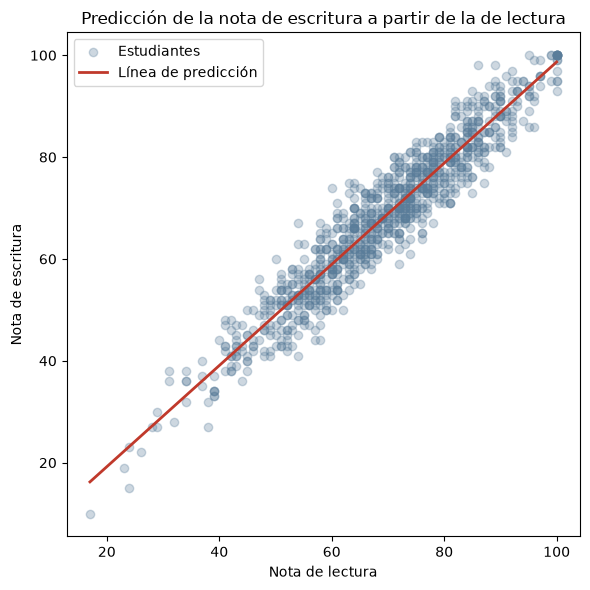

In [10]:
m, b = np.polyfit(df['reading score'], df['writing score'], 1)
print(f"writing score ≈ {m:.2f} * reading score + {b:.2f}")

# Ejemplo: estimar la nota de escritura de un estudiante con 70 en lectura
lectura_ejemplo = 70
estimado = m * lectura_ejemplo + b
print(f"Si un estudiante saca {lectura_ejemplo} en lectura, se estima ≈ {estimado:.1f} en escritura")

x_linea = np.array([df['reading score'].min(), df['reading score'].max()])
y_linea = m * x_linea + b

plt.figure(figsize=(6, 6))
plt.scatter(df['reading score'], df['writing score'], alpha=0.3, color='#5a7d9a', label='Estudiantes')
plt.plot(x_linea, y_linea, color='#c0392b', linewidth=2, label='Línea de predicción')
plt.title('Predicción de la nota de escritura a partir de la de lectura')
plt.xlabel('Nota de lectura')
plt.ylabel('Nota de escritura')
plt.legend()
plt.tight_layout()
plt.show()

Esta idea — encontrar una línea o fórmula que prediga un valor a partir de otro — es exactamente el punto de partida de los modelos de inteligencia artificial que se verán más adelante en el curso.

---

## 8. Probabilidad básica

Si eliges un estudiante al azar de la tabla, ¿qué tan probable es que haya hecho el curso de preparación? Es simplemente la frecuencia relativa que vimos en la Sección 1, expresada como probabilidad.

In [11]:
p_completo = (df['test preparation course'] == 'completed').mean()
p_notable = (df['math score'] >= 80).mean()

print(f"P(hizo el curso de preparación) = {p_completo:.1%}")
print(f"P(sacó 80 o más en matemáticas) = {p_notable:.1%}")

P(hizo el curso de preparación) = 35.8%
P(sacó 80 o más en matemáticas) = 19.3%


---

## Síntesis

En este notebook usamos los mismos 1000 estudiantes para cubrir las herramientas básicas de estadística descriptiva:

- **Frecuencias**, para resumir columnas de categorías (género).
- **Media, mediana y moda**, para encontrar el "dato típico" de una columna numérica (notas de matemáticas).
- **Rango y desviación estándar**, para saber qué tan parejos están los datos.
- **Cuartiles**, para ubicar a un estudiante dentro del grupo (diagrama de caja incluido).
- **Comparación entre grupos**, para ver si el curso de preparación hizo diferencia.
- **Correlación**, para medir si dos materias suben y bajan juntas.
- **Regresión lineal**, para predecir una nota a partir de otra.
- **Probabilidad**, para responder "¿qué tan probable es...?" eligiendo un estudiante al azar.

**Ejercicio propuesto:** repite la Sección 6 y 7 pero comparando `math score` contra `writing score` en vez de `reading score` contra `writing score`. ¿La correlación es más fuerte o más débil? ¿Por qué crees que pasa eso?